# Module A - Segmentation comparison

Runs **all 7 methods on the same 5 frames** and saves a side-by-side comparison grid.

Cell 1 finds the project root and your video automatically - set `VIDEO` yourself only if the
auto-detection picks the wrong clip.

In [1]:
import os, sys
from pathlib import Path


def find_root(start):
    """Walk up from the notebook's CWD looking for the project (it has both common.py and pipeline.py).

    Using '../' alone is wrong whenever Jupyter is launched from the project root rather than from
    module_A_segmentation/, which is the usual case.
    """
    for p in [Path(start).resolve(), *Path(start).resolve().parents]:
        if (p / "common.py").is_file() and (p / "pipeline.py").is_file():
            return p
    raise RuntimeError("could not locate the project root - run Jupyter from inside cv_conveyor/")


ROOT = find_root(os.getcwd())
sys.path.insert(0, str(ROOT))
from common import read_video, estimate_background, OUT
from module_A_segmentation.segmentation import METHODS, build_grid, pick_frames, segment_boxes

# Auto-detect a video: prefer data/conveyor.mp4, else the first clip under data/.
VIDEO = os.environ.get("VIDEO")
if not VIDEO:
    cand = ROOT / "data" / "conveyor.mp4"
    clips = sorted(p for p in (ROOT / "data").rglob("*")
                   if p.suffix.lower() in (".mp4", ".avi", ".mov", ".mkv"))
    VIDEO = str(cand if cand.is_file() else (clips[0] if clips else ""))
if not VIDEO or not os.path.isfile(VIDEO):
    raise FileNotFoundError("no video found - put your clip at data/conveyor.mp4 or set VIDEO=")

print("project root:", ROOT)
print("video       :", VIDEO)

frames, fps, _ = read_video(VIDEO, resize_width=640)
bg = estimate_background(frames)
print(f"{len(frames)} frames @ {fps:.1f} fps, background from {bg.shape[1]}x{bg.shape[0]}")
print("methods:", len(METHODS))

project root: C:\Users\HP\Desktop\Camera-Based Conveyor Inspection & Tracking System\cv_conveyor_project\cv_conveyor
video       : C:\Users\HP\Desktop\Camera-Based Conveyor Inspection & Tracking System\cv_conveyor_project\cv_conveyor\data\conveyor.mp4


402 frames @ 50.0 fps, background from 640x360
methods: 8


In [2]:
import numpy as np


def touching_pairs(boxes, min_frac=0.02):
    """Count box pairs whose bounding boxes overlap by more than min_frac of the smaller area.

    The assignment's Module A conclusion is specifically about touching/overlapping boxes, so the
    comparison grid has to actually contain such a pair for that conclusion to be checkable.
    """
    import cv2
    bs = [cv2.boundingRect(b["contour"]) for b in boxes]
    hits = []
    for i in range(len(bs)):
        for j in range(i + 1, len(bs)):
            ax, ay, aw, ah = bs[i]
            bx, by, bw, bh = bs[j]
            ow = min(ax + aw, bx + bw) - max(ax, bx)
            oh = min(ay + ah, by + bh) - max(ay, by)
            if ow > 0 and oh > 0:
                inter = ow * oh
                if inter > min_frac * min(aw * ah, bw * bh):
                    hits.append((i, j, inter / min(aw * ah, bw * bh)))
    return hits


idx = pick_frames(frames, 5)
print("the 5 compared frames:", list(map(int, idx)))
total_pairs = 0
for k, i in enumerate(idx):
    dets = segment_boxes(frames[i], bg)
    tp = touching_pairs(dets)
    total_pairs += len(tp)
    print(f"  frame {int(i):4d}: {len(dets)} boxes, {len(tp)} touching/overlapping pair(s)")
if total_pairs == 0:
    print("\n*** NO touching/overlapping boxes in any of the 5 frames. ***")
    print("The watershed claim below cannot be checked against this grid. Re-shoot so that two boxes")
    print("slightly overlap or touch edge-to-edge for part of the clip, then re-run this notebook.")
else:
    print(f"\n{total_pairs} touching/overlapping pair(s) present - the grid can support the verdict.")

the 5 compared frames: [40, 120, 201, 281, 361]
  frame   40: 12 boxes, 4 touching/overlapping pair(s)


  frame  120: 5 boxes, 0 touching/overlapping pair(s)
  frame  201: 6 boxes, 1 touching/overlapping pair(s)


  frame  281: 6 boxes, 0 touching/overlapping pair(s)
  frame  361: 8 boxes, 1 touching/overlapping pair(s)

6 touching/overlapping pair(s) present - the grid can support the verdict.


In [3]:
out_png = str(OUT / 'A_segmentation_grid.png')
build_grid(frames, bg, out_png, n=5)   # all methods, same 5 frames, one row per frame
print('saved', out_png)

  frame 40 | 1 Active contour

  (0.3s)
  frame 40 | 2 Split & merge

  (0.3s)
  frame 40 | 3 Watershed

  (0.0s)
  frame 40 | 4a Region split only

  (0.1s)
  frame 40 | 4b Region merge only

...

  (0.1s)
  frame 361 | 5 Felzenszwalb

    [RAG: 100 nodes / 245 edges, mean degree 4.90] 
  (0.9s)
  frame 361 | 6 Mean shift

  (1.6s)
  frame 361 | 7 Normalized cut

  (0.8s)


Saved C:\Users\HP\Desktop\Camera-Based Conveyor Inspection & Tracking System\cv_conveyor_project\cv_conveyor\outputs\A_segmentation_grid.png
saved C:\Users\HP\Desktop\Camera-Based Conveyor Inspection & Tracking System\cv_conveyor_project\cv_conveyor\outputs\A_segmentation_grid.png


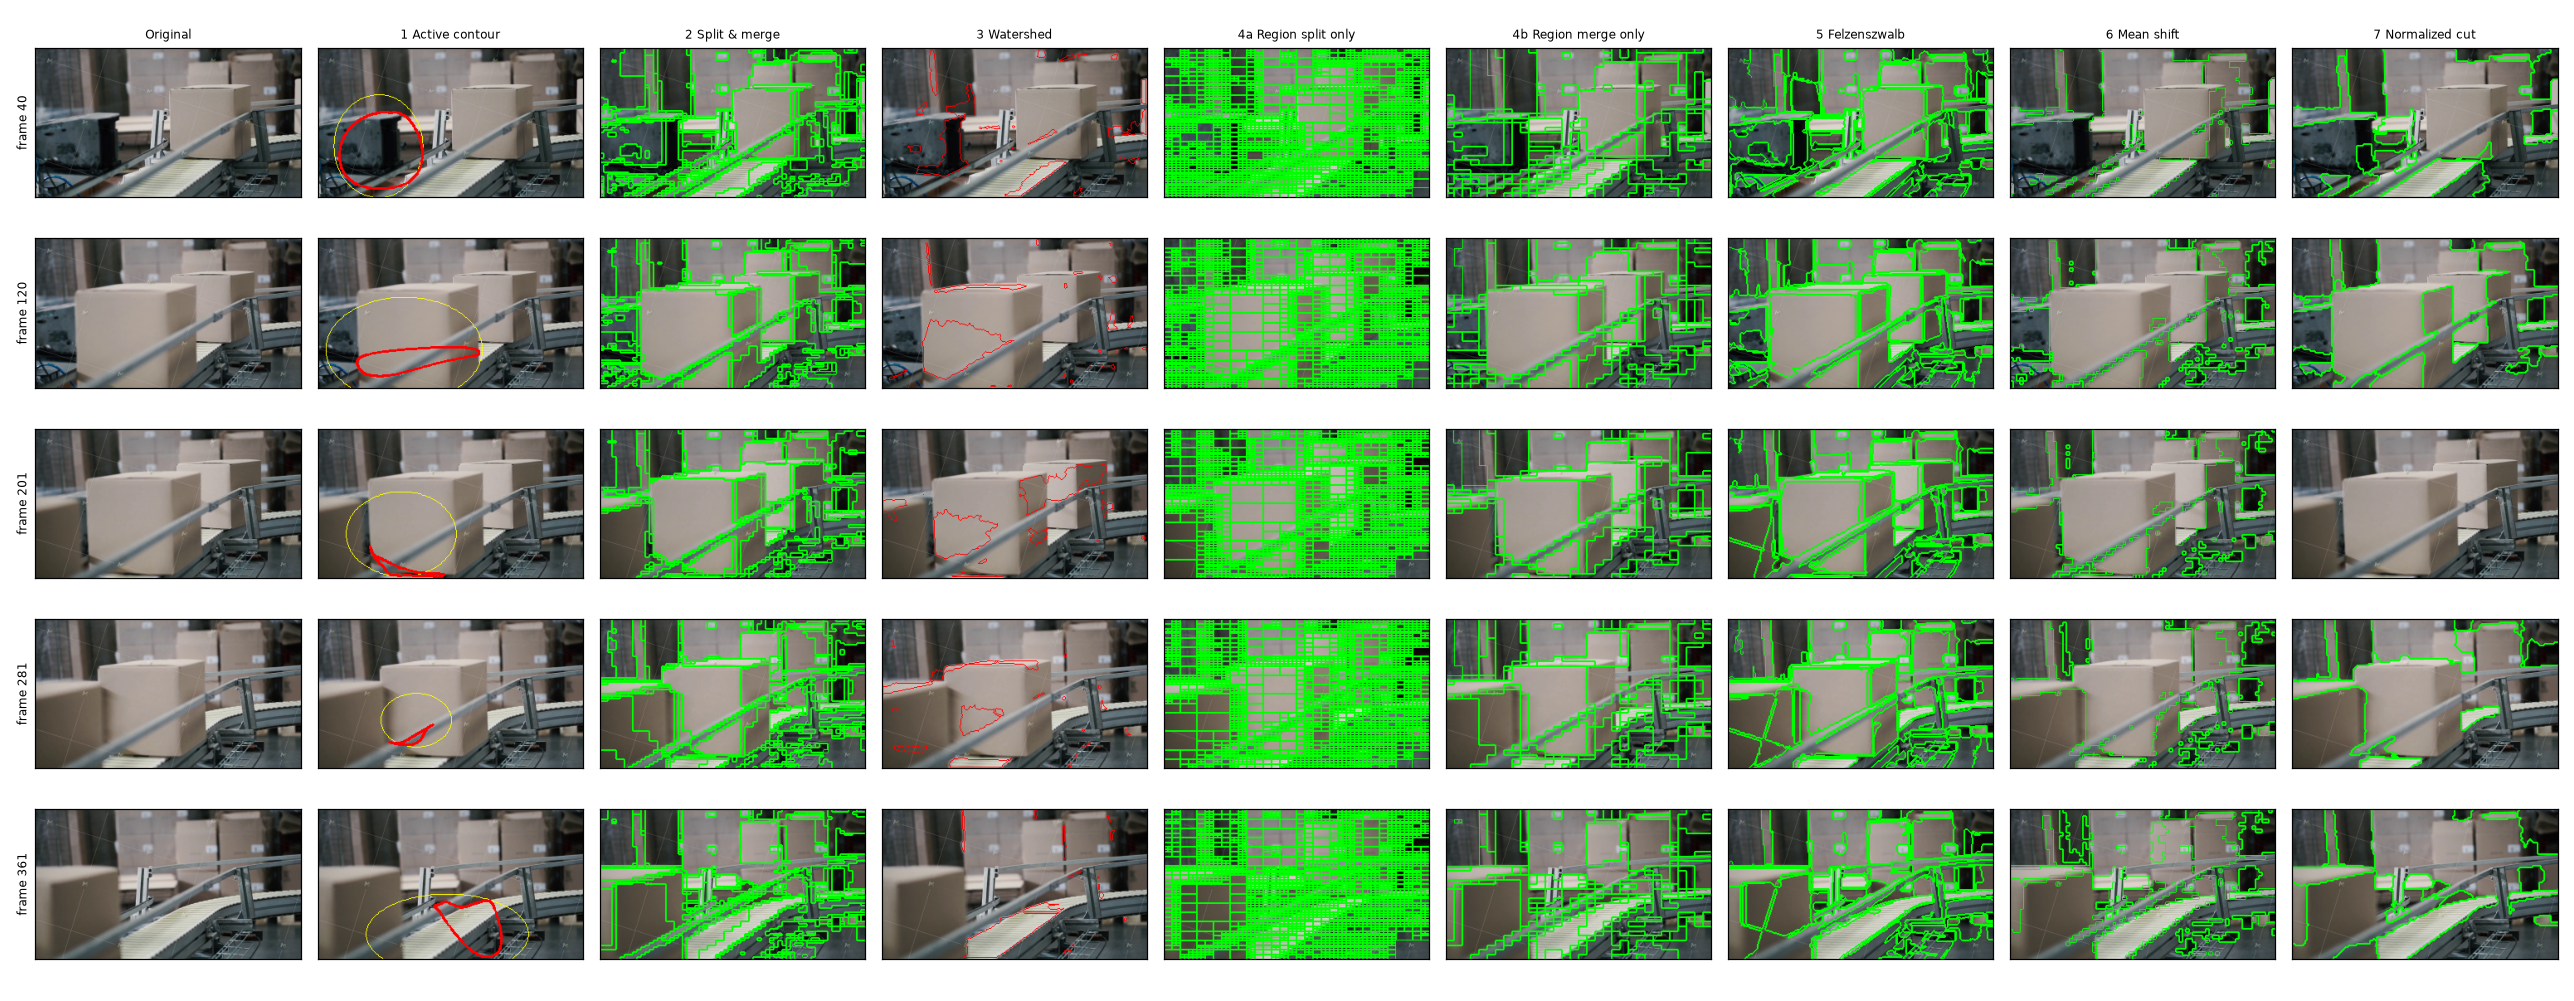

In [4]:
from IPython.display import Image, display
display(Image(out_png))

In [5]:
# ----------------------------------------------------------------------------------------------
# WHICH METHOD HANDLED TOUCHING / OVERLAPPING BOXES BEST, AND WHY?
#
# Claim (check it against the grid above and against the pair counts printed in cell 3 - if cell 3
# reported 0 touching pairs then this verdict is NOT supported by your footage and you must re-shoot):
# Watershed with distance-transform markers separated touching boxes best. The narrow "neck" where two
# boxes meet is a local minimum of the distance transform, so each box gets its own marker and the
# flooding front stops along that seam instead of merging the two blobs.
# The appearance-based methods (split&merge, Felzenszwalb, mean shift, N-cut) group pixels only by
# colour/intensity homogeneity, so two touching boxes of similar colour are pushed into ONE region;
# N-cut gives smoother, more shape-respecting boundaries but is still following colour, not shape.
# The active contour is the weakest here: it needs a manual initialisation, contours one box per run,
# and leaks through the faint edge between two touching boxes.
# ----------------------------------------------------------------------------------------------